# 03 Train BayesFlow

Person 3 notebook: train a BayesFlow neural posterior estimator on whitened noisy gravitational-wave strain data.

Expected dataset format:
- `X`: whitened strain signals, shape `(n_simulations, n_samples)`
- `theta`: true parameters, shape `(n_simulations, 6)`
- theta order: `[m1, m2, chi1, chi2, distance, inclination]`

In [4]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find project root from {cwd}")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATASET_PATH = PROJECT_ROOT / "data" / "gw_dataset_1000.npz"
MODEL_DIR = PROJECT_ROOT / "models" / "bayesflow_model"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH


PosixPath('/mnt/c/Users/batubaba/Desktop/sumos_proje/data/gw_dataset_1000.npz')

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from src.model import (
    PARAMETER_NAMES,
    history_to_losses,
    load_npz_dataset,
    sample_posterior,
    train_workflow,
)

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATASET_PATH}\n"
        "Create it first with notebooks/02_generate_dataset.ipynb, or run a Python script that calls "
        "DatasetGenerator(n_samples=1000, output_dir=PROJECT_ROOT / 'data').generate().\n"
        "On native Windows this requires the PyCBC/LALSuite stack, which is usually easier via WSL/Linux or conda-forge."
    )

dataset = load_npz_dataset(DATASET_PATH)
print("strain:", dataset["strain"].shape)
print("parameters:", dataset["parameters"].shape)
print("parameter order:", PARAMETER_NAMES)

strain: (1000, 8192, 1)
parameters: (1000, 6)
parameter order: ('m1', 'm2', 'chi1', 'chi2', 'distance', 'inclination')


## Training

Start with a small smoke test (`MAX_SAMPLES = 100` or `1000`). For the final run, set `MAX_SAMPLES = None` and point `DATASET_PATH` to `gw_dataset_10000.npz` if available.

In [6]:
MAX_SAMPLES = 1000
EPOCHS = 20
BATCH_SIZE = 64

workflow, history, train_data, val_data = train_workflow(
    dataset_path=DATASET_PATH,
    model_dir=MODEL_DIR,
    max_samples=MAX_SAMPLES,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

print("train strain:", train_data["strain"].shape)
print("validation strain:", val_data["strain"].shape)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model("/mnt/c/Users/batubaba/Desktop/sumos_proje/models/bayesflow_model/model.keras")
INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - loss: 8.5230 - val_loss: 8.4820
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - loss: 8.3729 - val_loss: 8.2462
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - loss: 8.2601 - val_loss: 8.1584
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - loss: 8.2384 - val_loss: 8.1593
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - loss: 8.2309 - val_loss: 8.1813
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - loss: 8.2276 - val_loss: 8.1863
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - loss: 8.2196 - val_loss: 8.1702
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - loss: 8.2131 - val_loss: 8.1712
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - loss: 8.2108 - val_loss: 8.1650
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - loss: 8.2109 - val_loss: 8.1812
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 55s 4s/step - loss: 8.2057 - val_loss: 8.1815
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - loss: 8.2073 - val_lo

INFO:bayesflow:Training completed in 19.49 minutes.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at '/mnt/c/Users/batubaba/Desktop/sumos_proje/models/bayesflow_model/model.keras'.
To load it, use approximator = keras.saving.load_model("/mnt/c/Users/batubaba/Desktop/sumos_proje/models/bayesflow_model/model.keras").


train strain: (900, 8192, 1)
validation strain: (100, 8192, 1)


PosixPath('/mnt/c/Users/batubaba/Desktop/sumos_proje/figures/training_loss.png')

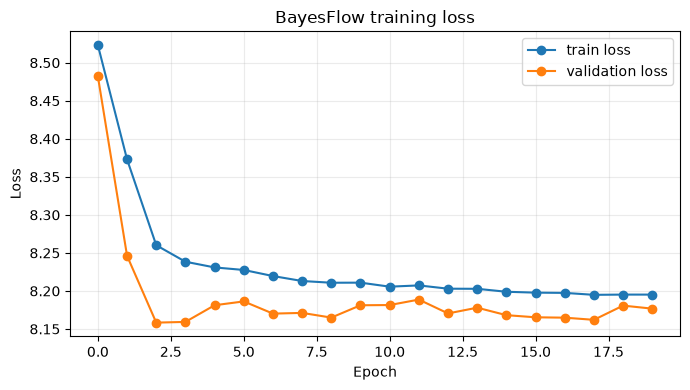

In [7]:
train_loss, val_loss = history_to_losses(history)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_loss, marker="o", label="train loss")
if val_loss is not None:
    ax.plot(val_loss, marker="o", label="validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("BayesFlow training loss")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

loss_path = FIGURE_DIR / "training_loss.png"
fig.savefig(loss_path, dpi=160)
loss_path

## Posterior Example

Draw posterior samples for one held-out validation strain and compare marginal posteriors with the true parameter values.

Sampling: 100%|██████████| 1/1 [00:00<00:00, 35.83batch/s]
INFO:bayesflow:Sampling completed in 1.87 seconds.


PosixPath('/mnt/c/Users/batubaba/Desktop/sumos_proje/figures/posterior_example.png')

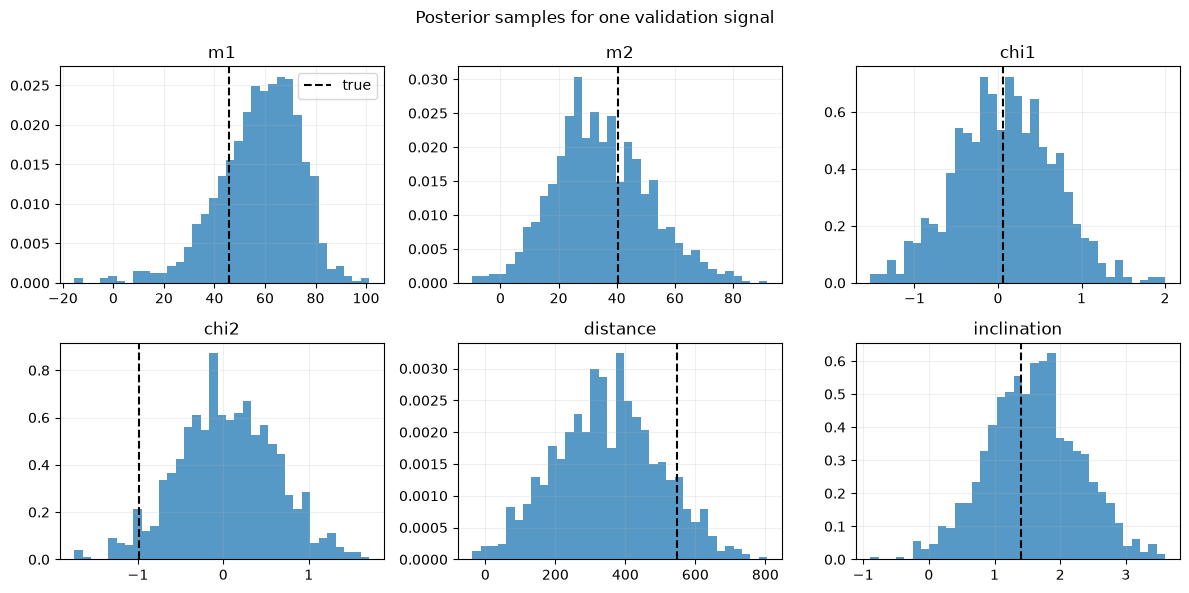

In [8]:
test_strain = val_data["strain"][0, :, 0]
true_theta = val_data["parameters"][0]
posterior_samples = sample_posterior(workflow, test_strain, num_samples=1000)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

for i, name in enumerate(PARAMETER_NAMES):
    axes[i].hist(posterior_samples[:, i], bins=35, density=True, alpha=0.75)
    axes[i].axvline(true_theta[i], color="black", linestyle="--", label="true")
    axes[i].set_title(name)
    axes[i].grid(alpha=0.2)

axes[0].legend()
fig.suptitle("Posterior samples for one validation signal")
fig.tight_layout()

posterior_path = FIGURE_DIR / "posterior_example.png"
fig.savefig(posterior_path, dpi=160)
posterior_path

In [9]:
posterior_mean = posterior_samples.mean(axis=0)
posterior_std = posterior_samples.std(axis=0)
absolute_error = np.abs(posterior_mean - true_theta)

for name, truth, mean, std, err in zip(PARAMETER_NAMES, true_theta, posterior_mean, posterior_std, absolute_error):
    print(f"{name:12s} true={truth:9.4f} posterior_mean={mean:9.4f} std={std:9.4f} abs_error={err:9.4f}")

best = PARAMETER_NAMES[int(np.argmin(absolute_error))]
worst = PARAMETER_NAMES[int(np.argmax(absolute_error))]
print(f"\nShort comment: In this validation example, {best} is closest to the true value and {worst} is least accurate by posterior mean absolute error.")

m1           true=  45.5631 posterior_mean=  57.8297 std=  16.2677 abs_error=  12.2665
m2           true=  40.5222 posterior_mean=  34.8088 std=  16.3676 abs_error=   5.7134
chi1         true=   0.0595 posterior_mean=   0.0793 std=   0.5847 abs_error=   0.0198
chi2         true=  -0.9821 posterior_mean=   0.0444 std=   0.5729 abs_error=   1.0264
distance     true= 547.1522 posterior_mean= 348.9351 std= 148.6155 abs_error= 198.2171
inclination  true=   1.3982 posterior_mean=   1.5865 std=   0.7015 abs_error=   0.1883

Short comment: In this validation example, chi1 is closest to the true value and distance is least accurate by posterior mean absolute error.


## Training Run Summary

This run validates the full BayesFlow training pipeline end-to-end on the generated 1000-sample dataset.

- Dataset: `data/gw_dataset_1000.npz`
- Dataset shape: `X = (1000, 8192)`, `theta = (1000, 6)`
- Max samples: `1000`
- Epochs: `20`
- Batch size: `64`
- Model checkpoint: `models/bayesflow_model/model.keras`
- Figures: `figures/training_loss.png`, `figures/posterior_example.png`

Result: the training run completed successfully. This confirms that dataset loading, train/validation splitting, BayesFlow training, checkpointing, loss plotting, and posterior plotting all work for the generated dataset.
